Recommended EDA practice structure

You can practice in this order:

1. Load the dataset
2. shape, head(), tail()
3. info()
4. Check missing values
5. Check duplicates
6. Statistical summary
7. Unique values
8. Categorical distributions
9. Numerical distributions
10. Outlier detection
11. Date/time analysis
12. Correlation analysis
13. Fraud vs non-fraud analysis
14. Feature relationships
15. Draw conclusions

#Fraud Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [3]:
df = pd.read_csv('C:/Users/ASUS/Downloads/Credit-Card-Fraud-EDA/data/test_eda_practice.csv')

## Load & Understand the Data

Q1. Load the CSV using Pandas. Read test_eda_practice.csv into a DataFrame called df. <br>
Q2. Find the number of rows, number of columns, first 5 rows, last 5 rows, and column names. <br>
Q3. Display the data types of every column. Identify numerical, categorical, and date/timestamp columns. <br>
Q4. Use .info(). Identify columns with missing values, suspicious data types, and columns with many unique values. <br>

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556469 entries, 0 to 556468
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             556469 non-null  int64  
 1   trans_date_trans_time  556469 non-null  str    
 2   cc_num                 556469 non-null  int64  
 3   merchant               555269 non-null  str    
 4   category               555567 non-null  str    
 5   amt                    555767 non-null  float64
 6   first                  556469 non-null  str    
 7   last                   556469 non-null  str    
 8   gender                 556438 non-null  str    
 9   street                 556469 non-null  str    
 10  city                   555668 non-null  str    
 11  state                  555868 non-null  str    
 12  zip                    556469 non-null  int64  
 13  lat                    556469 non-null  float64
 14  long                   556469 non-null  float64

In [ ]:
print(df.shape)
print(df.columns.values)
print(df.dtypes)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,1200
category,902
amt,702
first,0
last,0
gender,31
street,0


In [ ]:
print(df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0      220718   2020-09-07 19:19:21   345389171551808   
1      489009   2020-12-17 00:57:36   375767678113375   
2      326563   2020-10-24 13:23:13  4904681492230012   
3       63891   2020-07-13 12:31:00  3575789281659026   
4       82590   2020-07-20 04:38:39  6011693194885790   

                                merchant      category    amt        first  \
0                  fraud_Johnston-Casper        travel   6.73       Justin   
1                        fraud_Kuhic LLC  shopping_net   5.99  Christopher   
2  fraud_Wuckert, Wintheiser and Friesen          home  13.62         Lisa   
3                         fraud_Jast Ltd  shopping_net   7.35      Lindsay   
4      fraud_Schoen, Kuphal and Nitzsche   grocery_pos  95.50     Victoria   

        last gender                         street  ...      lat     long  \
0     Fowler      M    5569 Phillips Neck Apt. 003  ...  33.9215 -89.6782   
1  Patterson      M   16744 Campbe

In [ ]:
df.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
556464,110268,2020-07-29 08:13:47,377234009633447,"fraud_Rowe, Batz and Goodwin",grocery_pos,104.25,Theresa,Blackwell,F,43576 Kristina Islands,...,39.3716,-77.8229,1925,Systems developer,1966-02-14,bb6ca8c1b5034ba8a0a8cf9f0e61d553,1375085627,38.955449,-77.031434,0
556465,259178,2020-09-24 15:05:31,4992346398065154184,"fraud_Koss, Hansen and Lueilwitz",home,89.37,Benjamin,Kim,M,920 Patrick Light,...,41.1730,-89.2187,532,Audiological scientist,1956-01-09,ffe8dee3a48cb1fdc985e7fb3c7f8139,1380035131,40.448929,-88.357932,0
556466,365838,2020-11-10 03:23:15,4550599031376731,"fraud_Kerluke, Kertzmann and Wiza",misc_net,5.07,Angela,West,F,9471 Wong Islands,...,40.7559,-82.5123,92985,Press photographer,1968-05-29,ea12c7c3c04e054e51b12dc5cfd08b5b,1384053795,41.533541,-82.797399,0
556467,131932,2020-08-06 07:26:27,342351256941125,fraud_Rutherford-Mertz,grocery_pos,201.98,Rebecca,Obrien,F,5619 Mendoza Inlet,...,33.1194,-83.8235,3343,Theatre manager,1990-06-08,b6ee85d599affcbb1375184847ae81e8,1375773987,32.871628,-84.091574,0
556468,121958,2020-08-03 02:22:25,2576709887791552,fraud_McDermott-Rice,misc_pos,66.76,Joseph,Morgan,M,126 Underwood Drive,...,33.0067,-117.0690,1241364,Chartered public finance accountant,1959-08-05,2f0b366f2ffe20eecf9a072018b0c111,1375496545,33.690412,-117.447959,0


In [ ]:
print(df.is_fraud.value_counts())
print(df.is_fraud.value_counts()/len(df) * 100)

is_fraud
0    554321
1      2148
Name: count, dtype: int64
is_fraud
0    99.613995
1     0.386005
Name: count, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556469 entries, 0 to 556468
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             556469 non-null  int64  
 1   trans_date_trans_time  556469 non-null  object 
 2   cc_num                 556469 non-null  int64  
 3   merchant               555269 non-null  object 
 4   category               555567 non-null  object 
 5   amt                    555767 non-null  float64
 6   first                  556469 non-null  object 
 7   last                   556469 non-null  object 
 8   gender                 556438 non-null  object 
 9   street                 556469 non-null  object 
 10  city                   555668 non-null  object 
 11  state                  555868 non-null  object 
 12  zip                    556469 non-null  int64  
 13  lat                    556469 non-null  float64
 14  long                   556469 non-nu

## Data Cleaning

Q5. Find the number and percentage of missing valus per column. Which columns required attention? <br>
Q6. Check for duplicate rows. Find the number and percentage of duplicates. <br>
Q7 Investigate unique values for gender, category and state. Look for suspicious or inconsistent values. <br>
Q8. Check whether categorical values are consistently formatted. Look for differences in capitalization and unexpected spaces. Discover the problematic values yourself.

In [ ]:
Missing = df.isnull().sum()
print(Missing[Missing > 0])

merchant    1200
category     902
amt          702
gender        31
city         801
state        601
job         1000
dtype: int64


In [ ]:
print(Missing[Missing > 0]*100/len(df))

merchant    0.215645
category    0.162093
amt         0.126153
gender      0.005571
city        0.143943
state       0.108002
job         0.179705
dtype: float64


As per question no. 5, We need to pay attention on merchant and job columns

In [ ]:
print(df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0      220718   2020-09-07 19:19:21   345389171551808   
1      489009   2020-12-17 00:57:36   375767678113375   
2      326563   2020-10-24 13:23:13  4904681492230012   
3       63891   2020-07-13 12:31:00  3575789281659026   
4       82590   2020-07-20 04:38:39  6011693194885790   

                                merchant      category    amt        first  \
0                  fraud_Johnston-Casper        travel   6.73       Justin   
1                        fraud_Kuhic LLC  shopping_net   5.99  Christopher   
2  fraud_Wuckert, Wintheiser and Friesen          home  13.62         Lisa   
3                         fraud_Jast Ltd  shopping_net   7.35      Lindsay   
4      fraud_Schoen, Kuphal and Nitzsche   grocery_pos  95.50     Victoria   

        last gender                         street  ...      lat     long  \
0     Fowler      M    5569 Phillips Neck Apt. 003  ...  33.9215 -89.6782   
1  Patterson      M   16744 Campbe

In [ ]:
duplicates = df.duplicated()
print(duplicates[duplicates == True])
print(duplicates.sum()) #Number of duplicate rows in datasets
print(duplicates.sum() * 100/len(df)) #Percentage of duplicate rows in datasets

14485     True
20153     True
23029     True
24120     True
33969     True
          ... 
554106    True
554177    True
554427    True
555672    True
556431    True
Length: 743, dtype: bool
743
0.13352046565037765


As per question no. 5, We need to pay attention on merchant and job columns <br>
As per question no. 6, We have 743 duplicate rows (0.13%) <br>

In [ ]:
print(df.gender.unique())
print(df.category.unique())
print(df.state.unique())

['M' 'F' ' ' 'unknown' nan]
['travel' 'shopping_net' 'home' 'grocery_pos' 'personal_care'
 'gas_transport' 'misc_net' 'food_dining' 'entertainment' 'kids_pets'
 'shopping_pos' 'health_fitness' 'misc_pos' 'grocery_net' nan
 'HEALTH_FITNESS' 'HOME' 'SHOPPING_NET' 'GAS_TRANSPORT' 'MISC_NET'
 'GROCERY_POS' 'ENTERTAINMENT' 'KIDS_PETS' 'TRAVEL' 'GROCERY_NET'
 'PERSONAL_CARE' 'SHOPPING_POS' 'MISC_POS' 'FOOD_DINING']
['MS' 'VA' 'NY' 'MO' 'MN' 'NE' 'PA' 'TN' 'OR' 'IL' 'AL' 'NC' 'CO' 'MI'
 'SD' 'TX' 'OH' 'MT' 'CA' 'IN' 'ND' 'IA' 'AZ' 'SC' 'WI' 'MD' 'OK' 'AR'
 'GA' 'WV' 'WA' 'FL' 'ME' 'VT' 'KS' 'KY' 'LA' 'ID' 'DC' 'NJ' 'CT' 'NM'
 'WY' 'UT' 'NV' 'MA' 'NH' 'AK' 'HI' nan 'RI' ' NC ' ' TX ' ' CA ' ' NJ '
 ' FL ' ' WI ' ' MI ' ' VA ' ' KY ' ' AL ' ' OH ' ' MS ' ' IA ' ' IN '
 ' WA ' ' VT ' ' LA ' ' TN ' ' NY ' ' OK ' ' MN ' ' PA ' ' WV ' ' GA '
 ' MD ' ' KS ' ' ID ' ' NV ' ' OR ' ' MO ' ' WY ' ' SC ' ' IL ' ' MT '
 ' MA ' ' NE ' ' HI ' ' NH ' ' AR ' ' UT ' ' ME ' ' ND ' ' SD ' ' NM ']


In [ ]:
df['category'] = df['category'].str.strip().str.lower()
df['state'] = df['state'].str.strip().str.upper()

In [ ]:
print(df.category.unique())
print(df.state.unique())

['travel' 'shopping_net' 'home' 'grocery_pos' 'personal_care'
 'gas_transport' 'misc_net' 'food_dining' 'entertainment' 'kids_pets'
 'shopping_pos' 'health_fitness' 'misc_pos' 'grocery_net' nan]
['MS' 'VA' 'NY' 'MO' 'MN' 'NE' 'PA' 'TN' 'OR' 'IL' 'AL' 'NC' 'CO' 'MI'
 'SD' 'TX' 'OH' 'MT' 'CA' 'IN' 'ND' 'IA' 'AZ' 'SC' 'WI' 'MD' 'OK' 'AR'
 'GA' 'WV' 'WA' 'FL' 'ME' 'VT' 'KS' 'KY' 'LA' 'ID' 'DC' 'NJ' 'CT' 'NM'
 'WY' 'UT' 'NV' 'MA' 'NH' 'AK' 'HI' nan 'RI']


In [ ]:
print(df.gender[df.gender == 'unknown'].value_counts())
print(df.gender[df.gender == ' '].value_counts())

gender
unknown    35
Name: count, dtype: int64
gender
    34
Name: count, dtype: int64


In [ ]:
df.gender = df.gender.str.strip()
print(df.gender.unique())

['M' 'F' '' 'unknown' nan]


In [ ]:
df.gender = df.gender.replace(['unknown', ''], np.nan)

In [ ]:
print(df.gender.unique())

['M' 'F' nan]


As per question no. 5, We need to pay attention on merchant and job columns <br>
As per question no. 6, We have 743 duplicate rows (0.13%) <br>
As per question no. 7, We have handled unique values for gender, category and state <br>

In [ ]:
print(df.select_dtypes(include=['object']).columns.values)

['trans_date_trans_time' 'merchant' 'category' 'first' 'last' 'gender'
 'street' 'city' 'state' 'job' 'dob' 'trans_num']


In [ ]:
for col in df[df.select_dtypes(include=['object']).columns.values]:
  df[col] = df[col].str.strip()

In [ ]:
print(Missing[Missing > 0])

merchant    1200
category     902
amt          702
gender        31
city         801
state        601
job         1000
dtype: int64


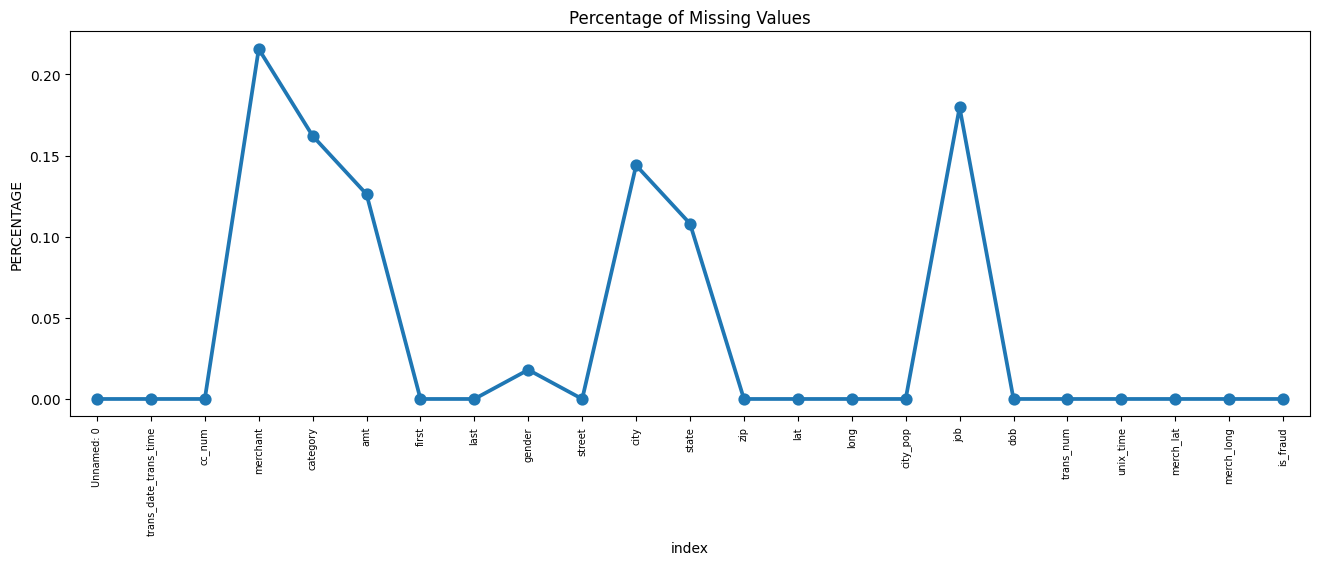

In [ ]:
missing = pd.DataFrame((df.isnull().sum()*100/df.shape[0])).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing Values")
plt.ylabel("PERCENTAGE")
plt.show()

In [ ]:
#for col in df[df.select_dtypes(include=['object']).columns.values]:
#  print(f'\n{col}\n')
#  print(df[col].unique())

As per question no. 5, We need to pay attention on merchant and job columns<br>
As per question no. 6, We have 743 duplicate rows (0.13%)<br>
As per question no. 7, We have handled unique values for gender, category and state <br>
As per question no. 8, We have checked whole columns if there is any difference in capitalization and unexpected spaces via above CODE!!

In [ ]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,556469.000000,5.564690e+05,555767.000000,556469.000000,556469.000000,556469.000000,5.564690e+05,5.564690e+05,556469.000000,556469.000000,556469.000000
mean,277850.268813,4.179787e+17,70.435235,48843.244174,38.543171,-90.232300,8.820391e+04,1.380679e+09,38.542715,-90.232337,0.003860
std,160422.650050,1.310049e+18,177.368706,26856.009369,5.061307,13.723167,3.003506e+05,5.201120e+06,5.095785,13.734492,0.062009
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.000000,1.800429e+14,9.640000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755544,-96.905490,0.000000
50%,277839.000000,3.521417e+15,47.330000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380761e+09,39.376444,-87.444964,0.000000
75%,416782.000000,4.635331e+15,83.080000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954034,-80.264595,0.000000
max,555718.000000,4.992346e+18,40092.494333,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [ ]:
df.merchant.value_counts()

,count
merchant,
fraud_Kilback LLC,1855
fraud_Cormier LLC,1596
fraud_Schumm PLC,1561
fraud_Dickinson Ltd,1521
fraud_Kuhn LLC,1519
...,...
fraud_Treutel-King,324
fraud_Satterfield-Lowe,320
fraud_Kessler Group,317


In [ ]:
#Group by spend category and ZIP, then fill with the mode of that group
df['merchant'] = df.groupby(['category', 'zip'])['merchant'].transform(
    lambda x:x.fillna(x.mode()[0]) if not x.mode().empty else 'unknown'
)

In [ ]:
df['category'] = df.groupby(['merchant'])['category'].transform(
    lambda x:x.fillna(x.mode()[0]) if not x.mode().empty else np.nan
)

In [ ]:
df['amt'] = df.groupby(['category'])['amt'].transform(
    lambda x: x.fillna(x.median())
)
df['amt'] = df['amt'].fillna(df['amt'].median())

In [ ]:
df['amt'].describe()

,amt
count,556469.000000
mean,70.367115
std,177.224253
min,1.000000
25%,9.660000
50%,47.310000
75%,82.970000
max,40092.494333


In [ ]:
df['amt_log'] = np.log1p(df['amt'])

<Axes: xlabel='amt_log', ylabel='Density'>

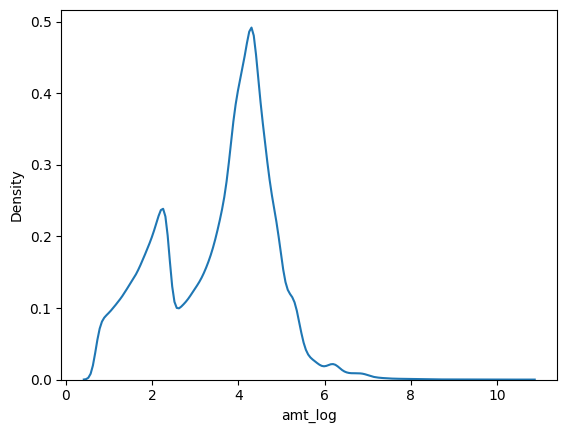

In [ ]:
sns.kdeplot(data=df['amt_log'])

In [ ]:
bins = [0, 10, 50, 100, 500, float('inf')]
labels = ['micro (<$10)', 'small ($10-$50)', 'medium ($50-$100)', 'high ($100-$500)', 'extreme (>$500)']

In [ ]:
df['amt_bin'] = pd.cut(df['amt'], bins=bins, labels=labels)

In [ ]:
df['amt_bin'].value_counts()*100/len(df)

,count
amt_bin,
medium ($50-$100),29.941111
small ($10-$50),26.172707
micro (<$10),25.893985
high ($100-$500),16.864192
extreme (>$500),1.128005


In [ ]:
df['category'] = df.groupby(['amt_bin'])['category'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'unknown'
)

/tmp/ipykernel_607/3755774560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['category'] = df.groupby(['amt_bin'])['category'].transform(


In [ ]:
df['merchant'] = df.groupby(['category', 'zip'])['merchant'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'unknown'
)

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
gender,100
city,801
state,601
job,1000


In [ ]:
df['job'] = df.groupby(['category'])['job'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else 'unknown'
)

In [ ]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [ ]:
df['state'] = df.groupby(['zip'])['state'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else np.nan
)

In [ ]:
df['city'] = df.groupby(['zip'])['city'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else np.nan
)

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


- here, we have handled all missing values very carefully and will go ahead for doing some analysis.

In [ ]:
df.columns.values

array(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant',
       'category', 'amt', 'first', 'last', 'gender', 'street', 'city',
       'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob',
       'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'amt_log', 'amt_bin'], dtype=object)

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_log,amt_bin
0,220718,2020-09-07 19:19:21,345389171551808,fraud_Johnston-Casper,travel,6.73,Justin,Fowler,M,5569 Phillips Neck Apt. 003,...,3451,Financial trader,1984-05-19,0e83a215e28eb901d2cae991842bd49a,1378581561,33.461035,-89.163702,0,2.045109,micro (<$10)
1,489009,2020-12-17 00:57:36,375767678113375,fraud_Kuhic LLC,shopping_net,5.99,Christopher,Patterson,M,16744 Campbell Wall Apt. 372,...,4367,Waste management officer,1962-04-12,296c6a56c062e30d8aa634149a46ee10,1387241856,37.659596,-78.771254,0,1.944481,micro (<$10)
2,326563,2020-10-24 13:23:13,4904681492230012,"fraud_Wuckert, Wintheiser and Friesen",home,13.62,Lisa,Lowe,F,574 David Locks Suite 207,...,722,Comptroller,1990-10-19,07758c9458c15bcde5bcb21ce58349d4,1382620993,41.633237,-75.038068,0,2.682390,small ($10-$50)
3,63891,2020-07-13 12:31:00,3575789281659026,fraud_Jast Ltd,shopping_net,7.35,Lindsay,Wilson,F,7618 Gonzales Mission,...,2368,Electronics engineer,1989-07-17,164359fecb16f577891094bed4e72ef0,1373718660,38.072499,-93.953653,0,2.122262,micro (<$10)
4,82590,2020-07-20 04:38:39,6011693194885790,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,95.50,Victoria,Fleming,F,2807 Parker Station Suite 080,...,2607,"Lecturer, further education",1995-12-04,f6d141bb8c6c74c10da11553eeef31e6,1374295119,45.159986,-93.436831,0,4.569543,medium ($50-$100)


In [ ]:
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
bins = [0, 25, 40, 60, 100]
labels = ['young adult (<25)', 'adult (25-40)', 'middle-age (40-60)', 'senior-citizens (60-100)']
df['age_bins'] = pd.cut(df.age, bins=bins, labels=labels)

In [ ]:
df['age_bins'].value_counts()

,count
age_bins,
middle-age (40-60),209816
adult (25-40),176484
senior-citizens (60-100),116204
young adult (<25),53965


In [ ]:
new_df = df.copy()

In [ ]:
new_df = new_df.drop(columns = ['age', 'amt', 'dob', 'trans_num', 'first', 'last', 'Unnamed: 0', 'street', 'unix_time' ])

In [ ]:
new_df.head()

,trans_date_trans_time,cc_num,merchant,category,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,amt_log,amt_bin,age_bins
0,2020-09-07 19:19:21,345389171551808,fraud_Johnston-Casper,travel,M,Coffeeville,MS,38922,33.9215,-89.6782,3451,Financial trader,33.461035,-89.163702,0,2.045109,micro (<$10),adult (25-40)
1,2020-12-17 00:57:36,375767678113375,fraud_Kuhic LLC,shopping_net,M,Timberville,VA,22853,38.6476,-78.7717,4367,Waste management officer,37.659596,-78.771254,0,1.944481,micro (<$10),middle-age (40-60)
2,2020-10-24 13:23:13,4904681492230012,"fraud_Wuckert, Wintheiser and Friesen",home,F,Cottekill,NY,12419,41.8467,-74.1038,722,Comptroller,41.633237,-75.038068,0,2.682390,small ($10-$50),adult (25-40)
3,2020-07-13 12:31:00,3575789281659026,fraud_Jast Ltd,shopping_net,F,Centerview,MO,64019,38.7897,-93.8702,2368,Electronics engineer,38.072499,-93.953653,0,2.122262,micro (<$10),adult (25-40)
4,2020-07-20 04:38:39,6011693194885790,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,F,Stanchfield,MN,55080,45.6675,-93.2433,2607,"Lecturer, further education",45.159986,-93.436831,0,4.569543,medium ($50-$100),young adult (<25)


In [ ]:
new_df['trans_hours'] = new_df['trans_date_trans_time'].dt.hour
new_df['trans_day_of_week'] = new_df['trans_date_trans_time'].dt.day_of_week
new_df = new_df.drop(columns=['trans_date_trans_time'])

In [ ]:
new_df.head()

,cc_num,merchant,category,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,amt_log,amt_bin,age_bins,trans_hours,trans_day_of_week
0,345389171551808,fraud_Johnston-Casper,travel,M,Coffeeville,MS,38922,33.9215,-89.6782,3451,Financial trader,33.461035,-89.163702,0,2.045109,micro (<$10),adult (25-40),19,0
1,375767678113375,fraud_Kuhic LLC,shopping_net,M,Timberville,VA,22853,38.6476,-78.7717,4367,Waste management officer,37.659596,-78.771254,0,1.944481,micro (<$10),middle-age (40-60),0,3
2,4904681492230012,"fraud_Wuckert, Wintheiser and Friesen",home,F,Cottekill,NY,12419,41.8467,-74.1038,722,Comptroller,41.633237,-75.038068,0,2.682390,small ($10-$50),adult (25-40),13,5
3,3575789281659026,fraud_Jast Ltd,shopping_net,F,Centerview,MO,64019,38.7897,-93.8702,2368,Electronics engineer,38.072499,-93.953653,0,2.122262,micro (<$10),adult (25-40),12,0
4,6011693194885790,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,F,Stanchfield,MN,55080,45.6675,-93.2433,2607,"Lecturer, further education",45.159986,-93.436831,0,4.569543,medium ($50-$100),young adult (<25),4,0


In [ ]:
df.cc_num.value_counts().head()

,count
cc_num,
6538441737335434,1475
4586810168620942,1470
4745996322265,1464
4587657402165341815,1462
2242542703101233,1430


## Numerical Analysis & Outliers Treatment

Q9. Use df.describe() and analyze amt, city_pop, lat, long, merch_lat, and merch_long.
Identify mean, median, minimum, maximum, and standard deviation. <br>
Q10. Analyze amt. Create a histogram and boxplot. Determine whether it is skewed and whether potential
outliers exist. <br>
Q11. Use the IQR method to identify outliers in amt. Calculate Q1, Q3, IQR, lower bound, upper bound,
and number of outliers.

In [ ]:
df.describe()

,Unnamed: 0,trans_date_trans_time,cc_num,amt,zip,lat,long,city_pop,dob,unix_time,merch_lat,merch_long,is_fraud,amt_log,age
count,556469.000000,556469,5.564690e+05,556469.000000,556469.000000,556469.000000,556469.000000,5.564690e+05,556469,5.564690e+05,556469.000000,556469.000000,556469.000000,556469.000000,556469.000000
mean,277850.268813,2020-10-02 01:49:32.544365568,4.179787e+17,70.367115,48843.244174,38.543171,-90.232300,8.820391e+04,1973-11-11 18:57:46.634080256,1.380679e+09,38.542715,-90.232337,0.003860,3.529927,46.423497
min,0.000000,2020-06-21 12:14:25,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1924-10-30 00:00:00,1.371817e+09,19.027422,-166.671575,0.000000,0.693147,15.000000
25%,138929.000000,2020-08-09 06:10:19,1.800429e+14,9.660000,26292.000000,34.668900,-96.798000,7.410000e+02,1962-09-27 00:00:00,1.376029e+09,34.755544,-96.905490,0.000000,2.366498,33.000000
50%,277839.000000,2020-10-03 00:40:03,3.521417e+15,47.310000,48174.000000,39.371600,-87.476900,2.408000e+03,1975-11-30 00:00:00,1.380761e+09,39.376444,-87.444964,0.000000,3.877639,44.000000
75%,416782.000000,2020-12-01 03:01:11,4.635331e+15,82.970000,72011.000000,41.894800,-80.175200,1.968500e+04,1987-04-23 00:00:00,1.385867e+09,41.954034,-80.264595,0.000000,4.430460,58.000000
max,555718.000000,2020-12-31 23:59:34,4.992346e+18,40092.494333,99921.000000,65.689900,-67.950300,2.906700e+06,2005-01-29 00:00:00,1.388534e+09,66.679297,-66.952026,1.000000,10.598969,96.000000
std,160422.650050,NaN,1.310049e+18,177.224253,26856.009369,5.061307,13.723167,3.003506e+05,NaN,5.201120e+06,5.095785,13.734492,0.062009,1.286653,17.442162


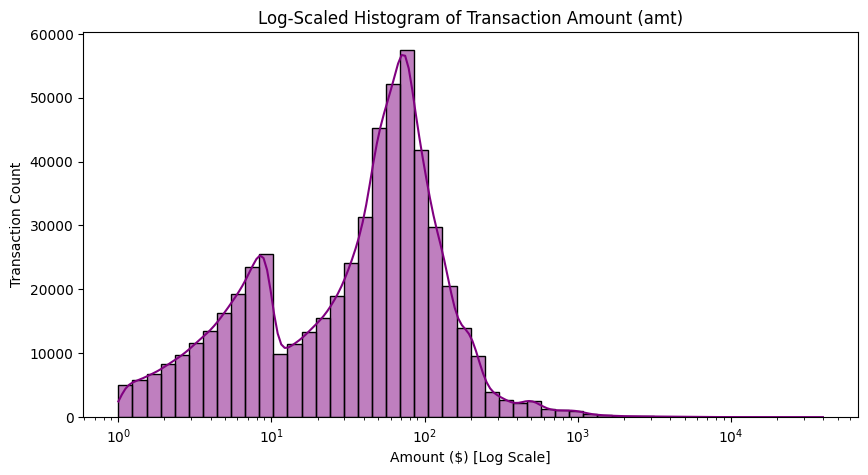

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['amt'], kde=True, log_scale=True,color='purple', bins=50)
plt.title("Log-Scaled Histogram of Transaction Amount (amt)")
plt.xlabel("Amount ($) [Log Scale]")
plt.ylabel("Transaction Count")
plt.show()

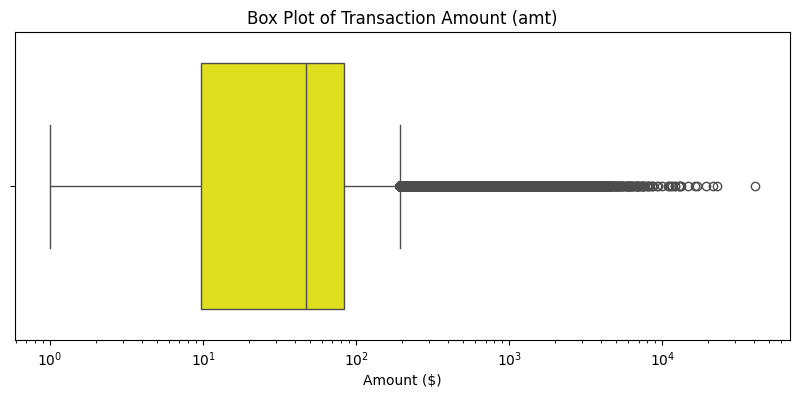

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amt'], color='yellow')
plt.xscale('log')
plt.title("Box Plot of Transaction Amount (amt)")
plt.xlabel("Amount ($)")
plt.show()

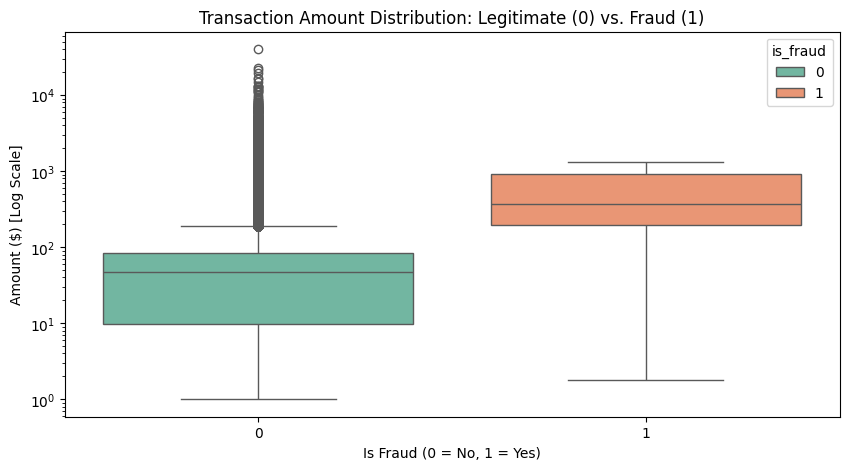

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_fraud', y='amt', data=df, palette='Set2', hue='is_fraud')
plt.yscale('log')  # Log scale handles the extreme vertical span
plt.title("Transaction Amount Distribution: Legitimate (0) vs. Fraud (1)")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Amount ($) [Log Scale]")
plt.show()

In [ ]:
IQR = 82.97 - 9.66
print('IQR:', IQR)
print('Upper Bound', 82.97 + 1.5 * IQR)
print('Lower Bound', 9.66 - 1.5 * IQR)

IQR: 73.31
Upper Bound 192.935
Lower Bound -100.305


## Categorical Analysis
Q12. Analyze gender. Create value counts and a bar chart. Calculate percentages and investigate
missing/unusual categories. <br>
Q13. Analyze category. Create a bar chart. Identify categories with the most and least transactions and
investigate inconsistent names. <br>
Q14. Find the Top 10 merchants based on transaction count and visualize them. <br>

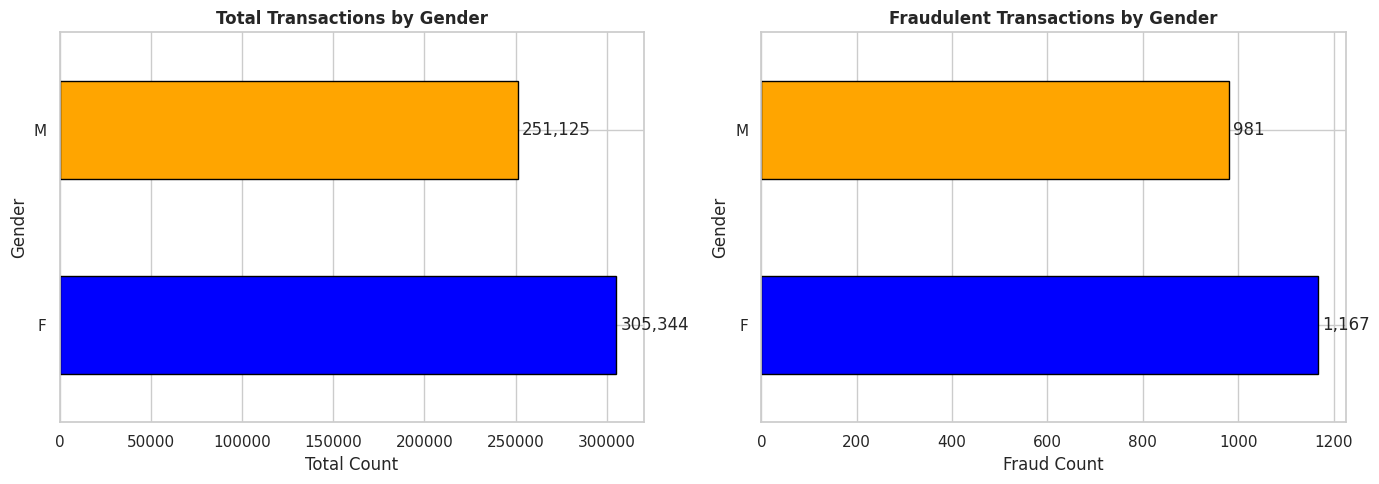

In [ ]:
# Set clean visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colors for gender (keeps visual consistency across both plots)
colors = ['blue', 'orange']

# Plot 1: Overall Gender Distribution
df['gender'].value_counts().plot(
    kind='barh', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Total Transactions by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Count')
axes[0].set_ylabel('Gender')

# Plot 2: Fraudulent Transactions by Gender
df[df['is_fraud'] == 1]['gender'].value_counts().plot(
    kind='barh', ax=axes[1], color=colors, edgecolor='black'
)
axes[1].set_title('Fraudulent Transactions by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fraud Count')
axes[1].set_ylabel('Gender')

# Add direct value labels inside/next to the bars
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# Standardize casing and replace underscores
new_df['category_clean'] = new_df['category'].str.lower().str.replace('_pos', '').str.replace('_net', '')

cat_counts = new_df['category_clean'].value_counts()
cat_percentages = new_df['category_clean'].value_counts(normalize=True) * 100
summary_df = pd.DataFrame({'Count': cat_counts,
                          'Percentage (%)': cat_percentages.round(2)})
most_trans = cat_counts.idxmax()
most_value = cat_counts.max()
min_trans = cat_counts.idxmin()
min_value = cat_counts.min()
print(f' Most_trans: {most_trans} \n Most_value: {most_value} \n Min_trans: {min_trans} \n Min_value: {min_value}')

 Most_trans: shopping 
 Most_value: 91540 
 Min_trans: travel 
 Min_value: 17438


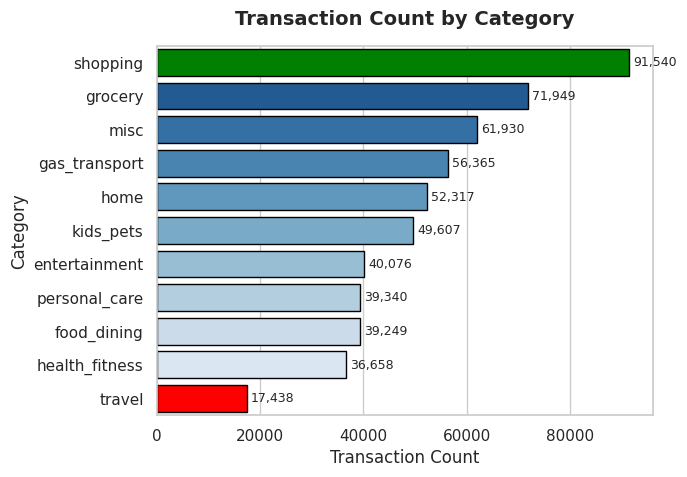

In [ ]:
sns.set_theme(style='whitegrid')
#Create barplot ordered by frequency
ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='Blues_r', edgecolor='black', hue=cat_counts.index)

#Highlight top and bottom bars with distinct colors
for bar, label in zip(ax.patches, cat_counts.index):
  if label == most_trans:
    bar.set_facecolor('Green')
  elif label == min_trans:
    bar.set_facecolor('Red')

plt.title('Transaction Count by Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Transaction Count', fontsize=12)
plt.ylabel('Category', fontsize=12)

for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9)

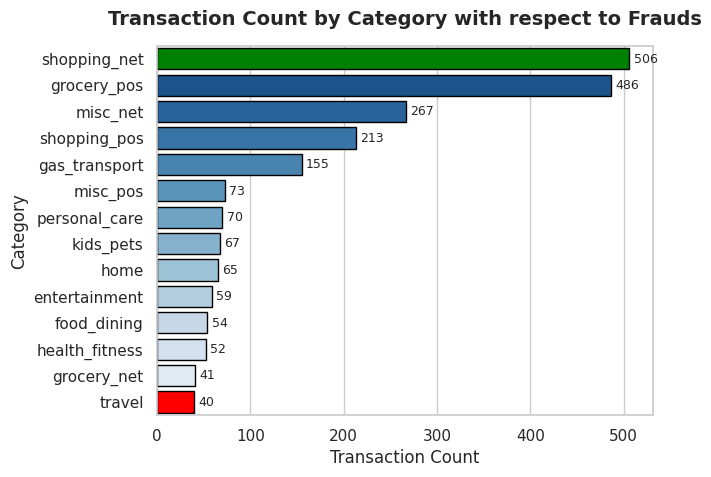

In [ ]:
cat_counts = new_df[new_df.is_fraud == 1]['category'].value_counts()
cat_percentages = new_df[new_df.is_fraud == 1]['category'].value_counts(normalize=True) * 100
summary_df = pd.DataFrame({'Count': cat_counts,
                          'Percentage (%)': cat_percentages.round(2)})
most_trans = cat_counts.idxmax()
most_value = cat_counts.max()
min_trans = cat_counts.idxmin()
min_value = cat_counts.min()

#Bar Chart of categories with respect to Frauds
sns.set_theme(style='whitegrid')
#Create barplot ordered by frequency
ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='Blues_r', edgecolor='black', hue=cat_counts.index)

#Highlight top and bottom bars with distinct colors
for bar, label in zip(ax.patches, cat_counts.index):
  if label == most_trans:
    bar.set_facecolor('Green')
  elif label == min_trans:
    bar.set_facecolor('Red')

plt.title('Transaction Count by Category with respect to Frauds', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Transaction Count', fontsize=12)
plt.ylabel('Category', fontsize=12)

for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9)

In [ ]:
merchant_counts = new_df['merchant'].value_counts()
merchant_percentages = new_df['merchant'].value_counts(normalize=True) * 100
top10_merchant = pd.DataFrame({'count': merchant_counts[0:10],
                               'percentage': merchant_percentages[0:10]})
print(top10_merchant)


                                   count  percentage
merchant                                            
fraud_Kilback LLC                   1855    0.333352
fraud_Cormier LLC                   1596    0.286808
fraud_Schumm PLC                    1561    0.280519
fraud_Dickinson Ltd                 1526    0.274229
fraud_Kuhn LLC                      1520    0.273151
fraud_Boyer PLC                     1502    0.269916
fraud_Emard Inc                     1224    0.219958
fraud_Parisian and Sons             1201    0.215825
fraud_Corwin-Collins                1181    0.212231
fraud_Schaefer, McGlynn and Bosco   1169    0.210075


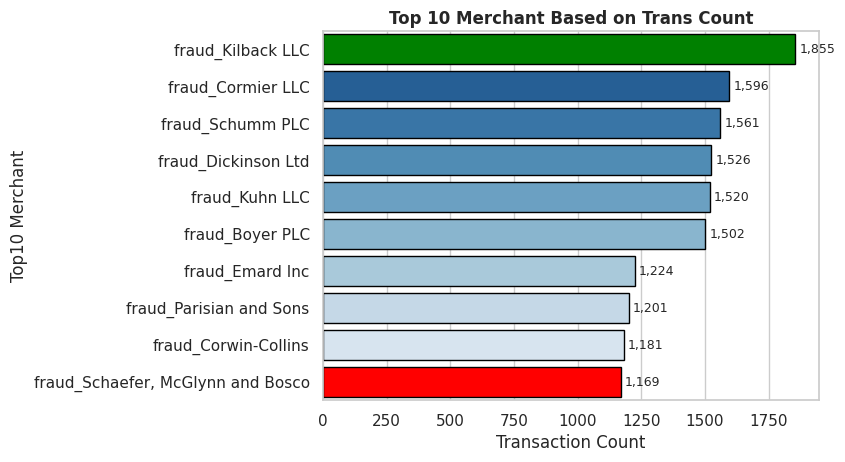

In [ ]:
sns.set_theme(style='whitegrid')

ax = sns.barplot(x=merchant_counts[0:10], y=merchant_counts.index[0:10], palette='Blues_r', edgecolor='black', hue=merchant_counts.index[0:10])

for bar, label in zip(ax.patches, merchant_counts.index[0:10]):
  if label == top10_merchant['count'].idxmax():
    bar.set_facecolor('Green')
  elif label == top10_merchant['count'].idxmin():
    bar.set_facecolor('Red')

plt.title("Top 10 Merchant Based on Trans Count", fontsize=12, fontweight='bold', pad=5)
plt.ylabel("Top10 Merchant", fontsize=12)
plt.xlabel('Transaction Count', fontsize=12)

for container in ax.containers:
  ax.bar_label(container, fontsize=9, padding=3, fmt='{:,.0f}')

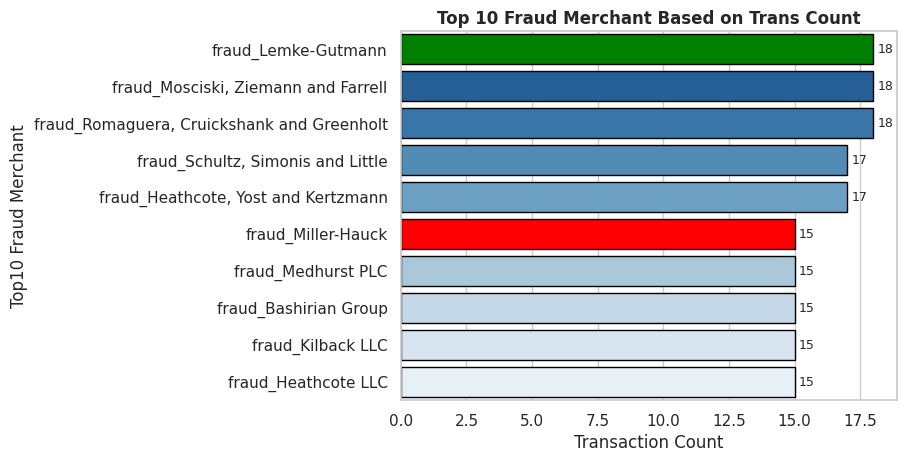

In [ ]:
fraud_merchant_counts = new_df[new_df.is_fraud == 1]['merchant'].value_counts()
fraud_merchant_percentages = new_df[new_df.is_fraud == 1]['merchant'].value_counts(normalize=True) * 100
top10_fraud_merchant = pd.DataFrame({'count': fraud_merchant_counts[0:10],
                               'percentage': fraud_merchant_percentages[0:10]})
sns.set_theme(style='whitegrid')

ax = sns.barplot(x=fraud_merchant_counts[0:10], y=fraud_merchant_counts.index[0:10], palette='Blues_r', edgecolor='black', hue=fraud_merchant_counts.index[0:10])

for bar, label in zip(ax.patches, fraud_merchant_counts.index[0:10]):
  if label == top10_fraud_merchant['count'].idxmax():
    bar.set_facecolor('Green')
  elif label == top10_fraud_merchant['count'].idxmin():
    bar.set_facecolor('Red')

plt.title("Top 10 Fraud Merchant Based on Trans Count", fontsize=12, fontweight='bold', pad=5)
plt.ylabel("Top10 Fraud Merchant", fontsize=12)
plt.xlabel('Transaction Count', fontsize=12)

for container in ax.containers:
  ax.bar_label(container, fontsize=9, padding=3, fmt='{:,.0f}')

In [ ]:
print(new_df.is_fraud.value_counts()*100/len(new_df))

is_fraud
0    99.613995
1     0.386005
Name: count, dtype: float64


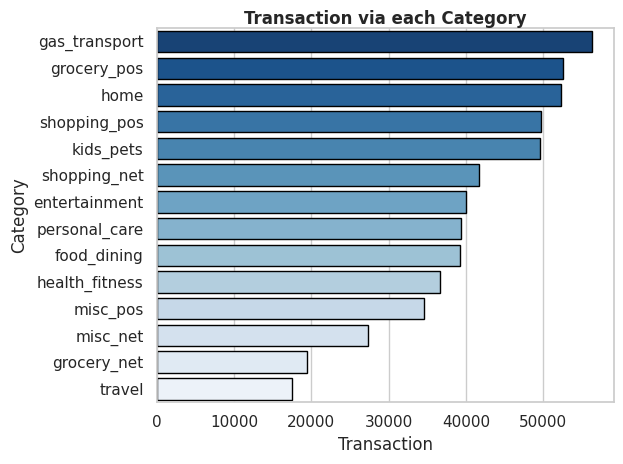

In [ ]:
sns.set_theme(style='whitegrid')
sns.barplot(x=new_df.category.value_counts(), y=new_df.category.value_counts().index, palette='Blues_r', edgecolor='black', hue=new_df.category.value_counts().index)
plt.title('Transaction via each Category', fontsize=12, fontweight='bold', pad=3)
plt.ylabel('Category', fontsize=12)
plt.xlabel('Transaction', fontsize=12)
plt.tight_layout()
plt.show()

## Fraud Analysis

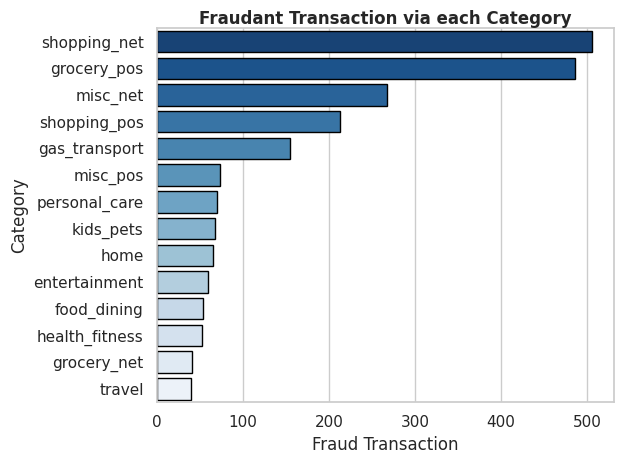

In [ ]:
category_fraud_count = new_df.category[new_df.is_fraud == 1].value_counts()
sns.set_theme(style='whitegrid')
sns.barplot(x=category_fraud_count, y=category_fraud_count.index, palette='Blues_r',edgecolor='black', hue=category_fraud_count.index)
plt.title('Fraudant Transaction via each Category', fontsize=12, fontweight='bold', pad=3)
plt.ylabel('Category', fontsize=12)
plt.xlabel('Fraud Transaction', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
amt_count = new_df.amt_bin.value_counts()
amt_fraud_count = new_df.amt_bin[new_df.is_fraud == 1].value_counts()
print(amt_count)
print(amt_fraud_count)

amt_bin
medium ($50-$100)    166613
small ($10-$50)      145643
micro (<$10)         144092
high ($100-$500)      93844
extreme (>$500)        6277
Name: count, dtype: int64
amt_bin
extreme (>$500)      1035
high ($100-$500)      627
small ($10-$50)       316
micro (<$10)          152
medium ($50-$100)      18
Name: count, dtype: int64


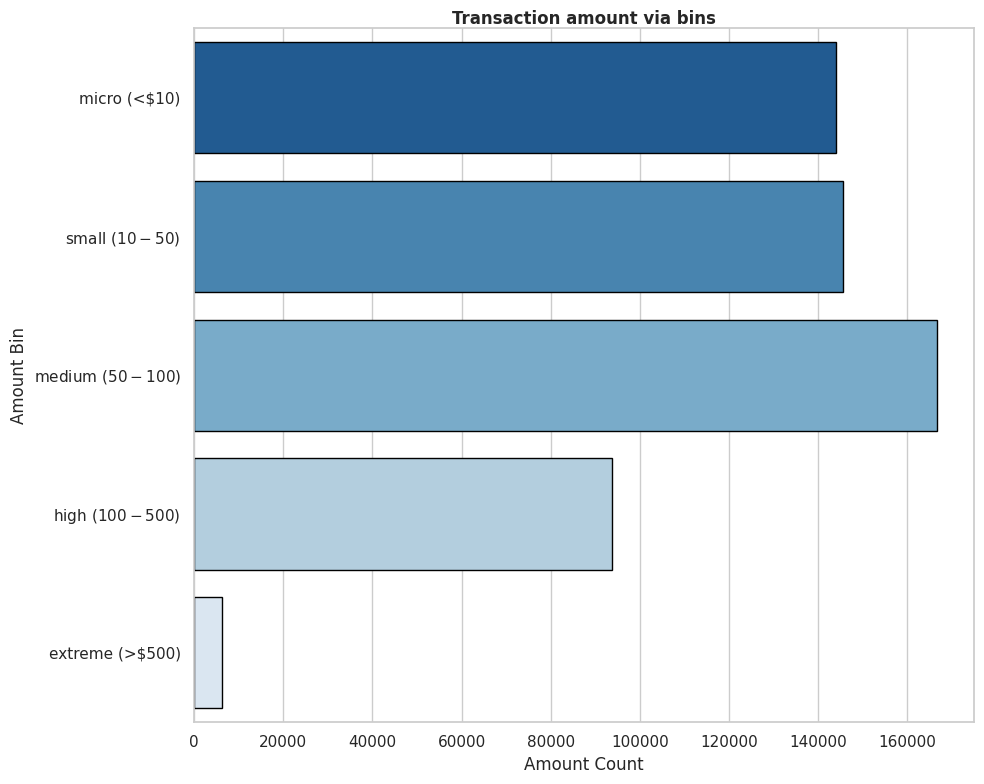

In [ ]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,8))
sns.barplot(x=amt_count, y=amt_count.index, palette='Blues_r', edgecolor='black', hue=amt_count.index)
plt.title('Transaction amount via bins', fontsize=12, fontweight='bold', pad=3)
plt.ylabel('Amount Bin', fontsize=12)
plt.xlabel('Amount Count', fontsize=12)
plt.tight_layout()
plt.show()

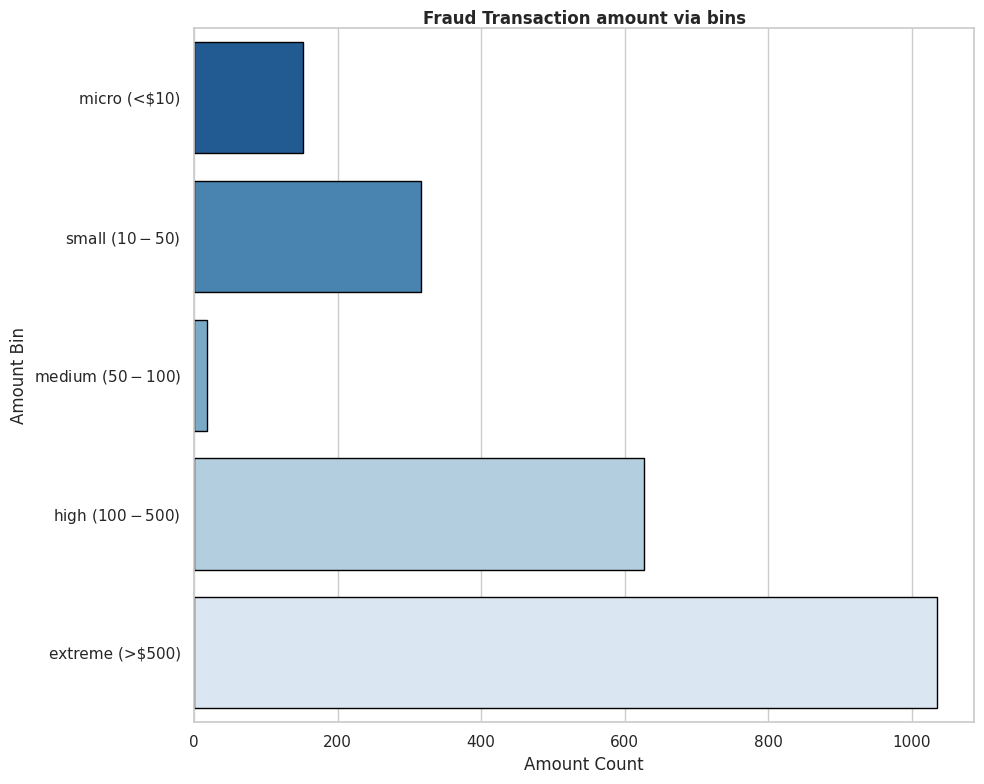

In [ ]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,8))
sns.barplot(x=amt_fraud_count, y=amt_fraud_count.index, palette='Blues_r', edgecolor='black', hue=amt_fraud_count.index)
plt.title('Fraud Transaction amount via bins', fontsize=12, fontweight='bold', pad=3)
plt.ylabel('Amount Bin', fontsize=12)
plt.xlabel('Amount Count', fontsize=12)
plt.tight_layout()
plt.show()

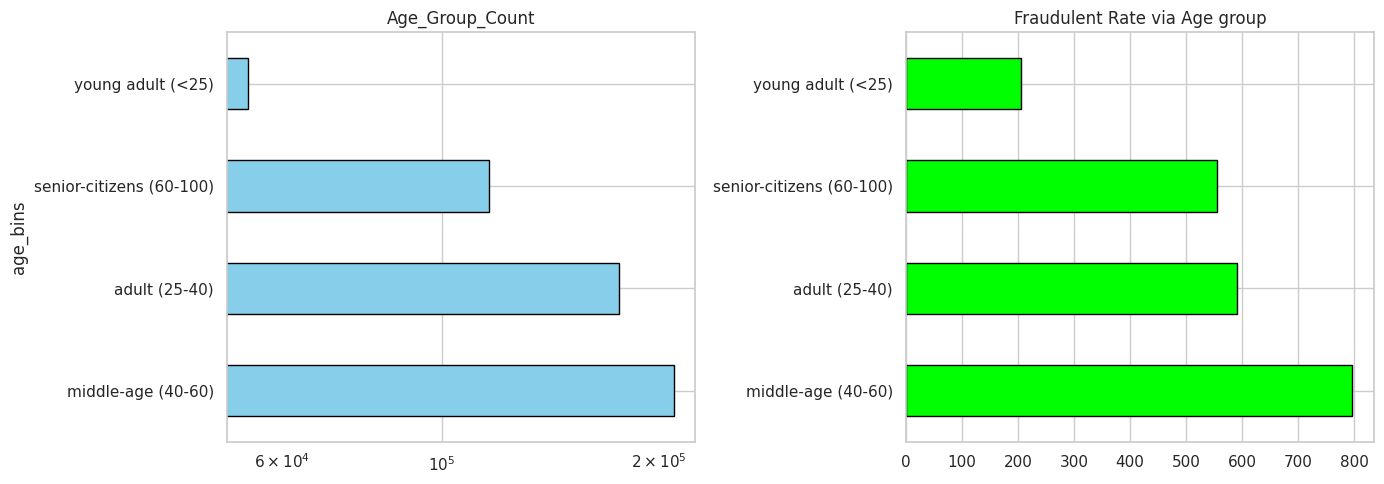

In [ ]:
age_count = new_df.age_bins.value_counts()
age_fraud_count = new_df.age_bins[new_df.is_fraud == 1].value_counts()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1,2,figsize=(14,5))

fig1 = age_count.plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
fig1.set_xscale('log')

fig2 = age_fraud_count.plot(kind='barh', ax=axes[1], color='lime', edgecolor='black')
fig2.set_ylabel('')

fig2.set_title("Fraudulent Rate via Age group")
fig1.set_title("Age_Group_Count")

plt.tight_layout()
plt.show()


In [ ]:
new_df.columns.values

array(['cc_num', 'merchant', 'category', 'gender', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long',
       'is_fraud', 'amt_log', 'amt_bin', 'age_bins', 'trans_hours',
       'trans_day_of_week', 'category_clean'], dtype=object)

In [ ]:
state_summary = new_df.groupby('state').agg(
    total_transactions = ('is_fraud', 'count'),
    fraud_transactions = ('is_fraud', 'sum'),
    fraud_rate_pct = ('is_fraud', lambda x: x.mean()*100)
).reset_index()

top10_fraud_state = state_summary.sort_values(by='fraud_rate_pct', ascending=False).head(10)
print(top10_fraud_state)

   state  total_transactions  fraud_transactions  fraud_rate_pct
0     AK                 845                  14        1.656805
6     CT                3281                  40        1.219141
12    ID                2492                  22        0.882825
10    HI                1093                   9        0.823422
25    MT                5060                  37        0.731225
7     DC                1520                  10        0.657895
14    IN               11974                  75        0.626357
24    MS                8843                  55        0.621961
36    OR                7828                  48        0.613183
44    VA               12527                  75        0.598707


In [ ]:
min_volume_threshold = 1000
filtered_states = state_summary[state_summary['total_transactions'] >= min_volume_threshold]

top_10_reliable_states = filtered_states.sort_values(
    by='fraud_rate_pct', ascending=False
).head(10)

print(f"--- Top 10 States by Fraud Rate (Min Volume >= {min_volume_threshold:,} Transactions) ---")
print(top_10_reliable_states.to_string(index=False))

--- Top 10 States by Fraud Rate (Min Volume >= 1,000 Transactions) ---
state  total_transactions  fraud_transactions  fraud_rate_pct
   CT                3281                  40        1.219141
   ID                2492                  22        0.882825
   HI                1093                   9        0.823422
   MT                5060                  37        0.731225
   DC                1520                  10        0.657895
   IN               11974                  75        0.626357
   MS                8843                  55        0.621961
   OR                7828                  48        0.613183
   VA               12527                  75        0.598707
   AZ                4595                  27        0.587595


## Date & Time Analysis

Q20. Convert trans_date_trans_time to a proper Pandas datetime type. Create year, month, day,
hour, and day-of-week features.<br>
Q21. Find transaction counts for every hour of the day and create a visualization.<br>
Q22. Calculate fraud rate by hour. Identify hours with higher and lower observed fraud rates.<br>
Q23. Analyze transaction volume and fraud rate by day of week.<br>

In [ ]:
new_df['trans_years'] = df['trans_date_trans_time'].dt.year
new_df['trans_days'] = df['trans_date_trans_time'].dt.day
new_df['trans_months'] = df['trans_date_trans_time'].dt.month

In [ ]:
hourly_count = new_df.trans_hours.value_counts().sort_index().reset_index()
hourly_count.columns = ['Hour', 'Transaction_Count']
print(hourly_count.to_string(index=False))

 Hour  Transaction_Count
    0              18180
    1              18487
    2              18167
    3              18222
    4              18096
    5              17943
    6              18131
    7              18122
    8              18020
    9              18074
   10              18069
   11              18108
   12              28083
   13              28209
   14              28248
   15              28080
   16              28604
   17              28099
   18              28041
   19              27963
   20              28023
   21              28235
   22              28425
   23              28840


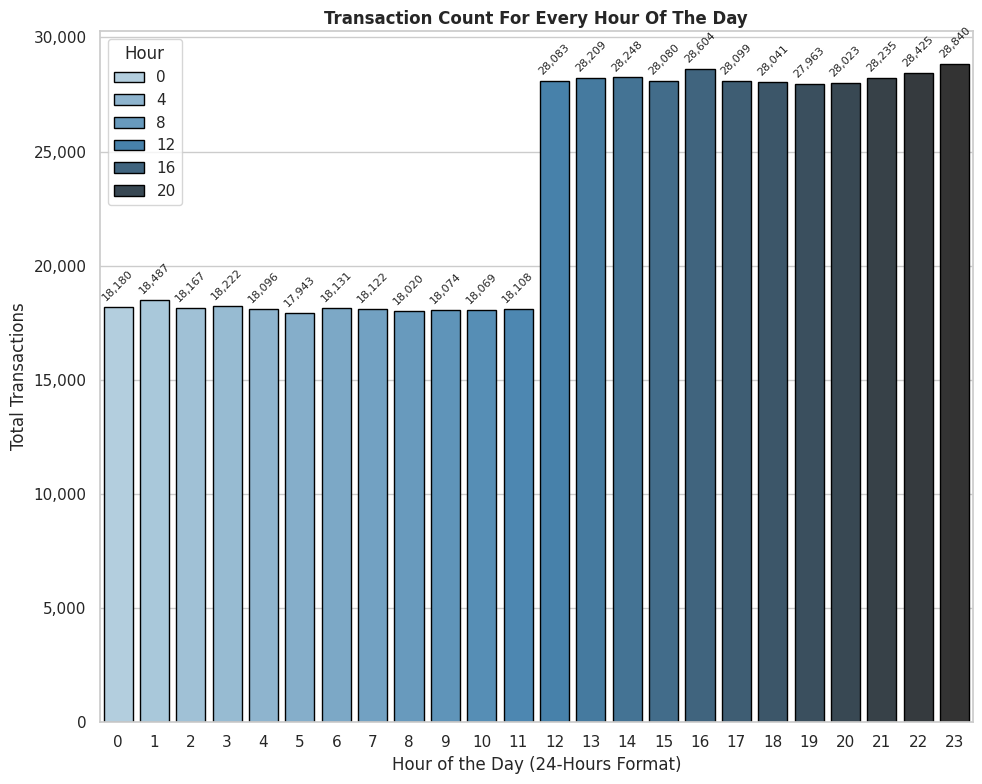

In [ ]:
from numpy.random import RandomState
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,8))
ax = sns.barplot(data=hourly_count, x='Hour', y='Transaction_Count', palette='Blues_d', edgecolor='black', hue='Hour')
plt.title('Transaction Count For Every Hour Of The Day', fontsize=12, fontweight='bold', pad=5)
plt.xlabel('Hour of the Day (24-Hours Format)', fontsize=12)
plt.ylabel('Total Transactions')

ax.yaxis.set_major_formatter('{x:,.0f}') #Formatting the y axis

for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
fraud_hourly_count = new_df.groupby('trans_hours').agg(
   transaction_count = ('is_fraud', 'count'),
   fraud_count=('is_fraud', 'sum'),
   fraud_rate = ('is_fraud', lambda x:x.mean() * 100)
)
fraud_hourly_count = fraud_hourly_count.sort_index().reset_index()
fraud_hourly_count.columns = ['Hour', 'Transaction', 'Fraud_Count', 'Fraud_Rate']
print(fraud_hourly_count.to_string(index=False))

 Hour  Transaction  Fraud_Count  Fraud_Rate
    0        18180          188    1.034103
    1        18487          169    0.914156
    2        18167          169    0.930258
    3        18222          194    1.064647
    4        18096           15    0.082891
    5        17943           20    0.111464
    6        18131           14    0.077216
    7        18122           16    0.088290
    8        18020           10    0.055494
    9        18074           14    0.077459
   10        18069           12    0.066412
   11        18108           17    0.093881
   12        28083           17    0.060535
   13        28209           14    0.049630
   14        28248           14    0.049561
   15        28080           21    0.074786
   16        28604           21    0.073416
   17        28099           16    0.056942
   18        28041           30    0.106986
   19        27963           25    0.089404
   20        28023           36    0.128466
   21        28235           27 

/tmp/ipykernel_607/2492478353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fraud_hourly_count, x='Hour', y='Fraud_Rate', palette='Blues_r', edgecolor='black')


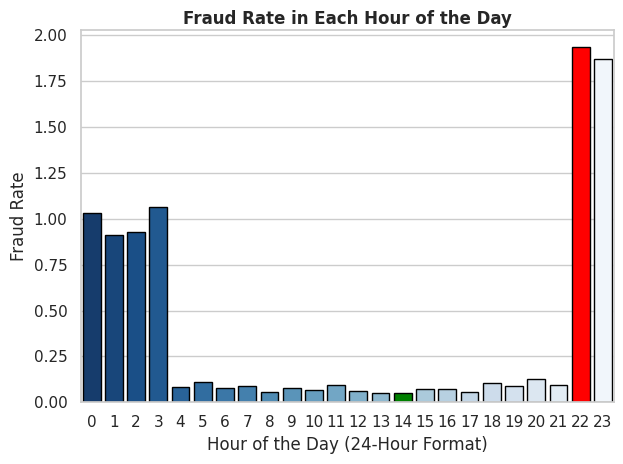

In [ ]:
max_fraud_rate = fraud_hourly_count.Fraud_Rate.max()
min_fraud_rate = fraud_hourly_count.Fraud_Rate.min()
sns.set_theme(style='whitegrid')

ax = sns.barplot(data=fraud_hourly_count, x='Hour', y='Fraud_Rate', palette='Blues_r', edgecolor='black')

for bar, label in zip(ax.patches, fraud_hourly_count.Fraud_Rate):
  if label == max_fraud_rate:
    bar.set_facecolor('Red')
  elif label == min_fraud_rate:
    bar.set_facecolor('Green')

plt.title("Fraud Rate in Each Hour of the Day", fontsize=12, fontweight='bold', pad=4)
plt.ylabel('Fraud Rate', fontsize=12)
plt.xlabel('Hour of the Day (24-Hour Format)')
plt.tight_layout()
plt.show()

In [ ]:
day_count = new_df.trans_day_of_week.value_counts().sort_index().reset_index()
day_count.columns = ['Day_of_Week', 'Transaction_Count']
print(day_count.to_string(index=False))

 Day_of_Week  Transaction_Count
           0             115295
           1             110259
           2              52932
           3              59525
           4              62882
           5              62364
           6              93212


/tmp/ipykernel_607/471917250.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=day_count, x='Day_of_Week', y='Transaction_Count', palette='Blues_d', edgecolor='black')


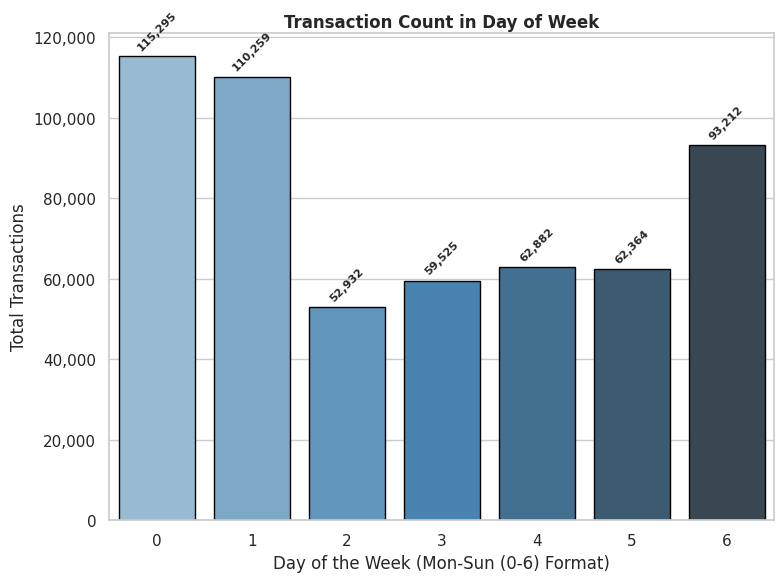

In [ ]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,6))
ax = sns.barplot(data=day_count, x='Day_of_Week', y='Transaction_Count', palette='Blues_d', edgecolor='black')

ax.yaxis.set_major_formatter('{x:,.0f}')
plt.title('Transaction Count in Day of Week', fontsize=12, fontweight='bold', pad=4)
plt.ylabel('Total Transactions', fontsize=12)
plt.xlabel('Day of the Week (Mon-Sun (0-6) Format)', fontsize=12)

for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}', rotation=45, fontsize=8, padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
fraud_day_count = new_df.groupby('trans_day_of_week').agg(
    transaction_count = ('is_fraud', 'count'),
    fraud_count = ('is_fraud', 'sum'),
    fraud_rate = ('is_fraud', lambda x: x.mean()*100)
)
fraud_day_count = fraud_day_count.reset_index()
fraud_day_count.columns = ['Day_Of_Week', 'Trans_Count', 'Fraud_Count', 'Fraud_Rate']
fraud_day_count

,Day_Of_Week,Trans_Count,Fraud_Count,Fraud_Rate
0,0,115295,302,0.261937
1,1,110259,333,0.302016
2,2,52932,266,0.502532
3,3,59525,309,0.519110
4,4,62882,297,0.472313
5,5,62364,267,0.428132
6,6,93212,374,0.401236


/tmp/ipykernel_607/3707755291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fraud_day_count, x='Day_Of_Week', y='Fraud_Rate', palette='Blues_r', edgecolor='black')


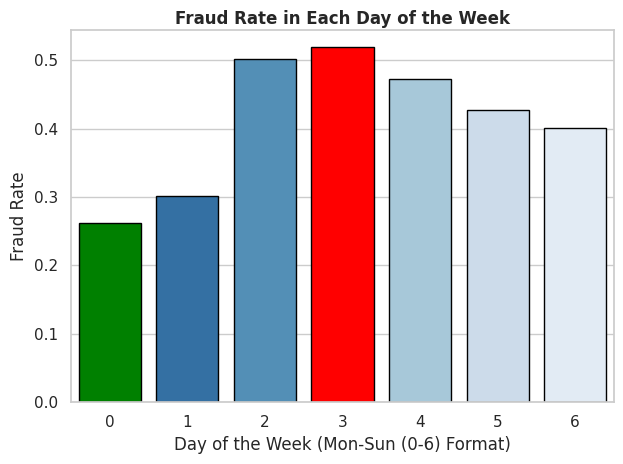

In [ ]:
max_fraud_rate = fraud_day_count.Fraud_Rate.max()
min_fraud_rate = fraud_day_count.Fraud_Rate.min()
sns.set_theme(style='whitegrid')

ax = sns.barplot(data=fraud_day_count, x='Day_Of_Week', y='Fraud_Rate', palette='Blues_r', edgecolor='black')

for bar, label in zip(ax.patches, fraud_day_count.Fraud_Rate):
  if label == max_fraud_rate:
    bar.set_facecolor('Red')
  elif label == min_fraud_rate:
    bar.set_facecolor('Green')

plt.title("Fraud Rate in Each Day of the Week", fontsize=12, fontweight='bold', pad=4)
plt.ylabel('Fraud Rate', fontsize=12)
plt.xlabel('Day of the Week (Mon-Sun (0-6) Format)')
plt.tight_layout()
plt.show()

## Customer Analysis
Q24. Use dob to calculate customer age. Find minimum, maximum, average, and median age.<br>
Q25. Investigate age data quality. Look for negative or extremely high ages and count affected records. Do
not clean them yet.<br>
Q26. Create age groups: *'<20, 20–29, 30–39, 40–49, 50–59, and 60+'*. Analyze transaction count, fraud
count, and fraud rate. <br>

In [ ]:
#df['age'] = (df['trans_data_trans_time] - df['dob']).dt.days // 365 #Already used in previous line
df.age.describe()

,age
count,556469.000000
mean,46.423497
std,17.442162
min,15.000000
25%,33.000000
50%,44.000000
75%,58.000000
max,96.000000


In [ ]:
age_summary = new_df.groupby('age_bins').agg(
    transaction_count = ('is_fraud', 'count'),
    fraud_count = ('is_fraud','sum'),
    fraud_rate = ('is_fraud', lambda x: x.mean() * 100)
).reset_index()
print(age_summary.to_string(index=False))

                age_bins  transaction_count  fraud_count  fraud_rate
       young adult (<25)              53965          205    0.379876
           adult (25-40)             176484          591    0.334875
      middle-age (40-60)             209816          796    0.379380
senior-citizens (60-100)             116204          556    0.478469


/tmp/ipykernel_607/3978131495.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = new_df.groupby('age_bins').agg(


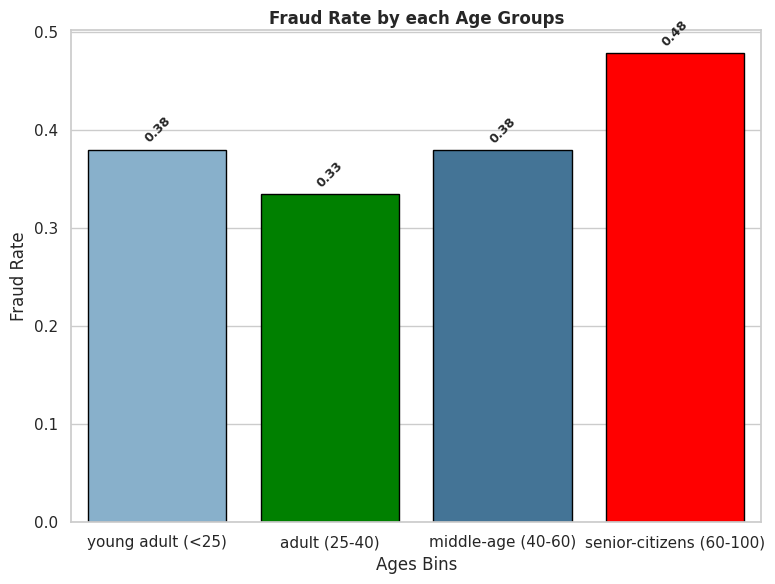

In [ ]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,6))
ax = sns.barplot(data=age_summary, x='age_bins', y='fraud_rate', palette='Blues_d', edgecolor='black', hue='age_bins')

for bar, label in zip(ax.patches, age_summary.fraud_rate):
  if label == age_summary.fraud_rate.max():
    bar.set_facecolor('Red')
  elif label == age_summary.fraud_rate.min():
    bar.set_facecolor('Green')

plt.xlabel('Ages Bins', fontsize=12)
plt.ylabel('Fraud Rate', fontsize=12)
plt.title('Fraud Rate by each Age Groups', fontsize=12, fontweight='bold', pad=4)

for container in ax.containers:
  ax.bar_label(container, fmt='{:.2f}', fontsize=9, rotation=45, padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

## Correlation & Relationships
Q27. Create a correlation matrix and heatmap for numerical variables. Identify strong and weak
correlations.<br>
Q28. Create a visualization comparing amt and is_fraud. Describe observed patterns.<br>
Q29. Investigate the apparent relationship between city_pop and amt.<br>

In [ ]:
corr_matrix = new_df.corr(numeric_only=True)
corr_matrix_is_fraud = new_df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)
corr_matrix_is_fraud

,is_fraud
is_fraud,1.000000
amt_log,0.097884
trans_hours,0.011695
trans_day_of_week,0.009339
lat,0.005840
merch_lat,0.005797
long,-0.001015
merch_long,-0.001104
cc_num,-0.001572
zip,-0.002265


In [ ]:
spearman_corr = new_df.corr(method='spearman', numeric_only=True)
spearman_corr_is_fraud = new_df.corr(method='spearman', numeric_only=True)['is_fraud'].sort_values(ascending=False)
spearman_corr_is_fraud

,is_fraud
is_fraud,1.000000
amt_log,0.071198
trans_hours,0.018778
trans_day_of_week,0.009979
lat,0.005073
merch_lat,0.005014
city_pop,0.003734
long,-0.000331
merch_long,-0.000451
zip,-0.002587


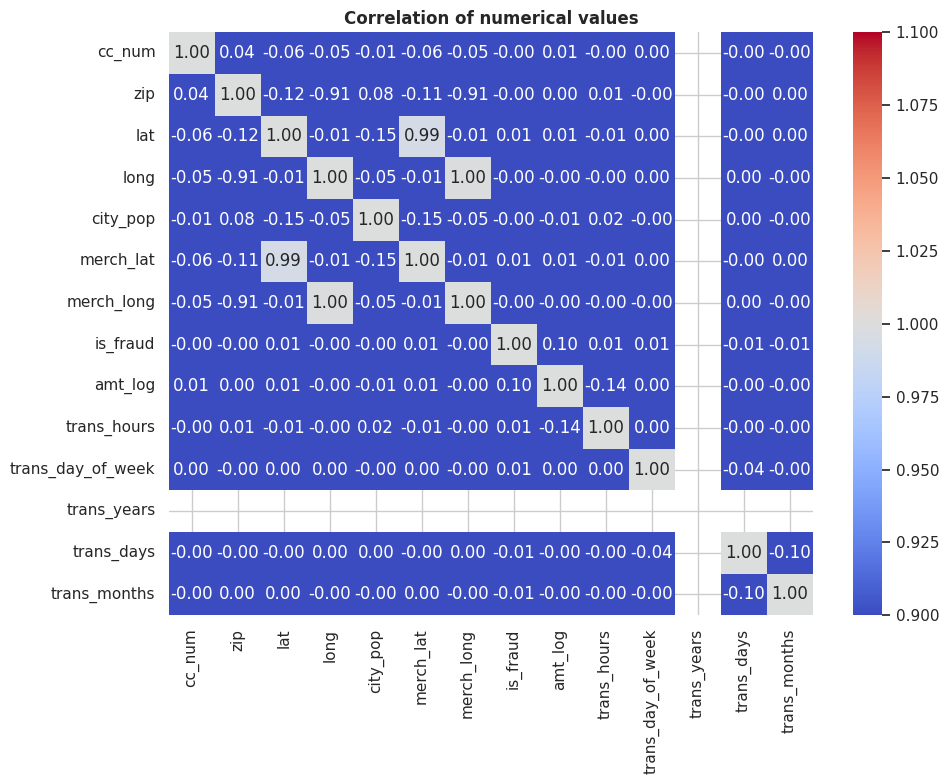

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data=new_df.corr(numeric_only=True), vmin=1, vmax=1, fmt='.2f', cmap='coolwarm', annot=True)
plt.title('Correlation of numerical values', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Advanced EDA Challenges
Q30. Find high-value transactions. Choose a threshold based on your EDA. Analyze count, fraud
percentage, categories, gender, and state.<br>
Q31. Build a summary of fraudulent transactions using category, amount, gender, state, city population,
hour, and day of week. Identify patterns without claiming correlation proves causation.<br>
Q32. Find merchants with the highest number of fraudulent transactions. Compare fraud count with total
transaction volume. Explain why fraud count alone can be misleading.<br>

In [ ]:
#As we know extreme amount is 500+
new_df['is_high_value'] = df['amt'] >= 500
print(new_df['is_high_value'].value_counts())
high_val_df = new_df[new_df['is_high_value']]
total_high_val_count = len(high_val_df)
pct_of_total_volume = (total_high_val_count / len(df)) * 100
pct_of_total_volume

is_high_value
False    550192
True       6277
Name: count, dtype: int64


1.1280053336304448

In [ ]:
high_val_fraud_count = high_val_df['is_fraud'].sum()
high_val_fraud_rate = high_val_df['is_fraud'].mean() * 100
normal_fraud_rate= new_df[~new_df['is_high_value']]['is_fraud'].mean() * 100
print('High Value Fraud Rate:',high_val_fraud_rate,'\nNormal Fraud Rate:', normal_fraud_rate)

High Value Fraud Rate: 16.488768519993627 
Normal Fraud Rate: 0.20229301771018116


In [ ]:
print(f"=== High-Value Transaction Summary (Threshold >= $500) ===")
print(f"High-Value Transaction Count : {total_high_val_count:,} ({pct_of_total_volume:.2f}% of total dataset)")
print(f"High-Value Fraud Rate        : {high_val_fraud_rate:.2f}% ({high_val_fraud_count:,} fraud cases)")
print(f"Normal-Value Fraud Rate      : {normal_fraud_rate:.2f}%")
print(f"Risk Multiplier              : {high_val_fraud_rate / normal_fraud_rate:.2f}x higher risk\n")

=== High-Value Transaction Summary (Threshold >= $500) ===
High-Value Transaction Count : 6,277 (1.13% of total dataset)
High-Value Fraud Rate        : 16.49% (1,035 fraud cases)
Normal-Value Fraud Rate      : 0.20%
Risk Multiplier              : 81.51x higher risk



In [ ]:
cat_summary = high_val_df.groupby('category').agg(
    high_val_count = ('is_fraud', 'count'),
    fraud_count = ('is_fraud', 'sum'),
    fraud_rate = ('is_fraud', lambda x:x.mean() * 100)
).sort_values(by='fraud_rate', ascending=False).reset_index()
print(cat_summary.head(10).to_string(index=False))


      category  high_val_count  fraud_count  fraud_rate
 entertainment              84           33   39.285714
      misc_net             877          266   30.330673
  shopping_net            1724          506   29.350348
  shopping_pos            1617          213   13.172542
      misc_pos             623           17    2.728732
   food_dining              21            0    0.000000
health_fitness              14            0    0.000000
   grocery_pos              37            0    0.000000
   grocery_net               9            0    0.000000
 gas_transport              26            0    0.000000


In [ ]:
gender_summary = high_val_df.groupby('gender').agg(
    high_val_count = ('is_fraud', 'count'),
    fraud_count = ('is_fraud', 'sum'),
    fraud_rate = ('is_fraud', lambda x:x.mean() * 100)
).sort_values(by='fraud_rate', ascending=False).reset_index()
print(gender_summary.to_string(index=False))

gender  high_val_count  fraud_count  fraud_rate
     M            3025          542   17.917355
     F            3252          493   15.159902


In [ ]:
state_summary = high_val_df.groupby('state').agg(
    high_val_count = ('is_fraud', 'count'),
    fraud_count = ('is_fraud', 'sum'),
    fraud_rate = ('is_fraud', lambda x:x.mean() * 100)
).query('high_val_count >=50').sort_values(by='fraud_rate', ascending=False).reset_index()

print(state_summary.head(10).to_string(index=False))

state  high_val_count  fraud_count  fraud_rate
   KY             132           37   28.030303
   IA             116           31   26.724138
   NM              87           23   26.436782
   VA             153           39   25.490196
   MT              65           16   24.615385
   MS             114           28   24.561404
   AZ              53           13   24.528302
   GA             125           30   24.000000
   NJ              99           23   23.232323
   MD             104           24   23.076923


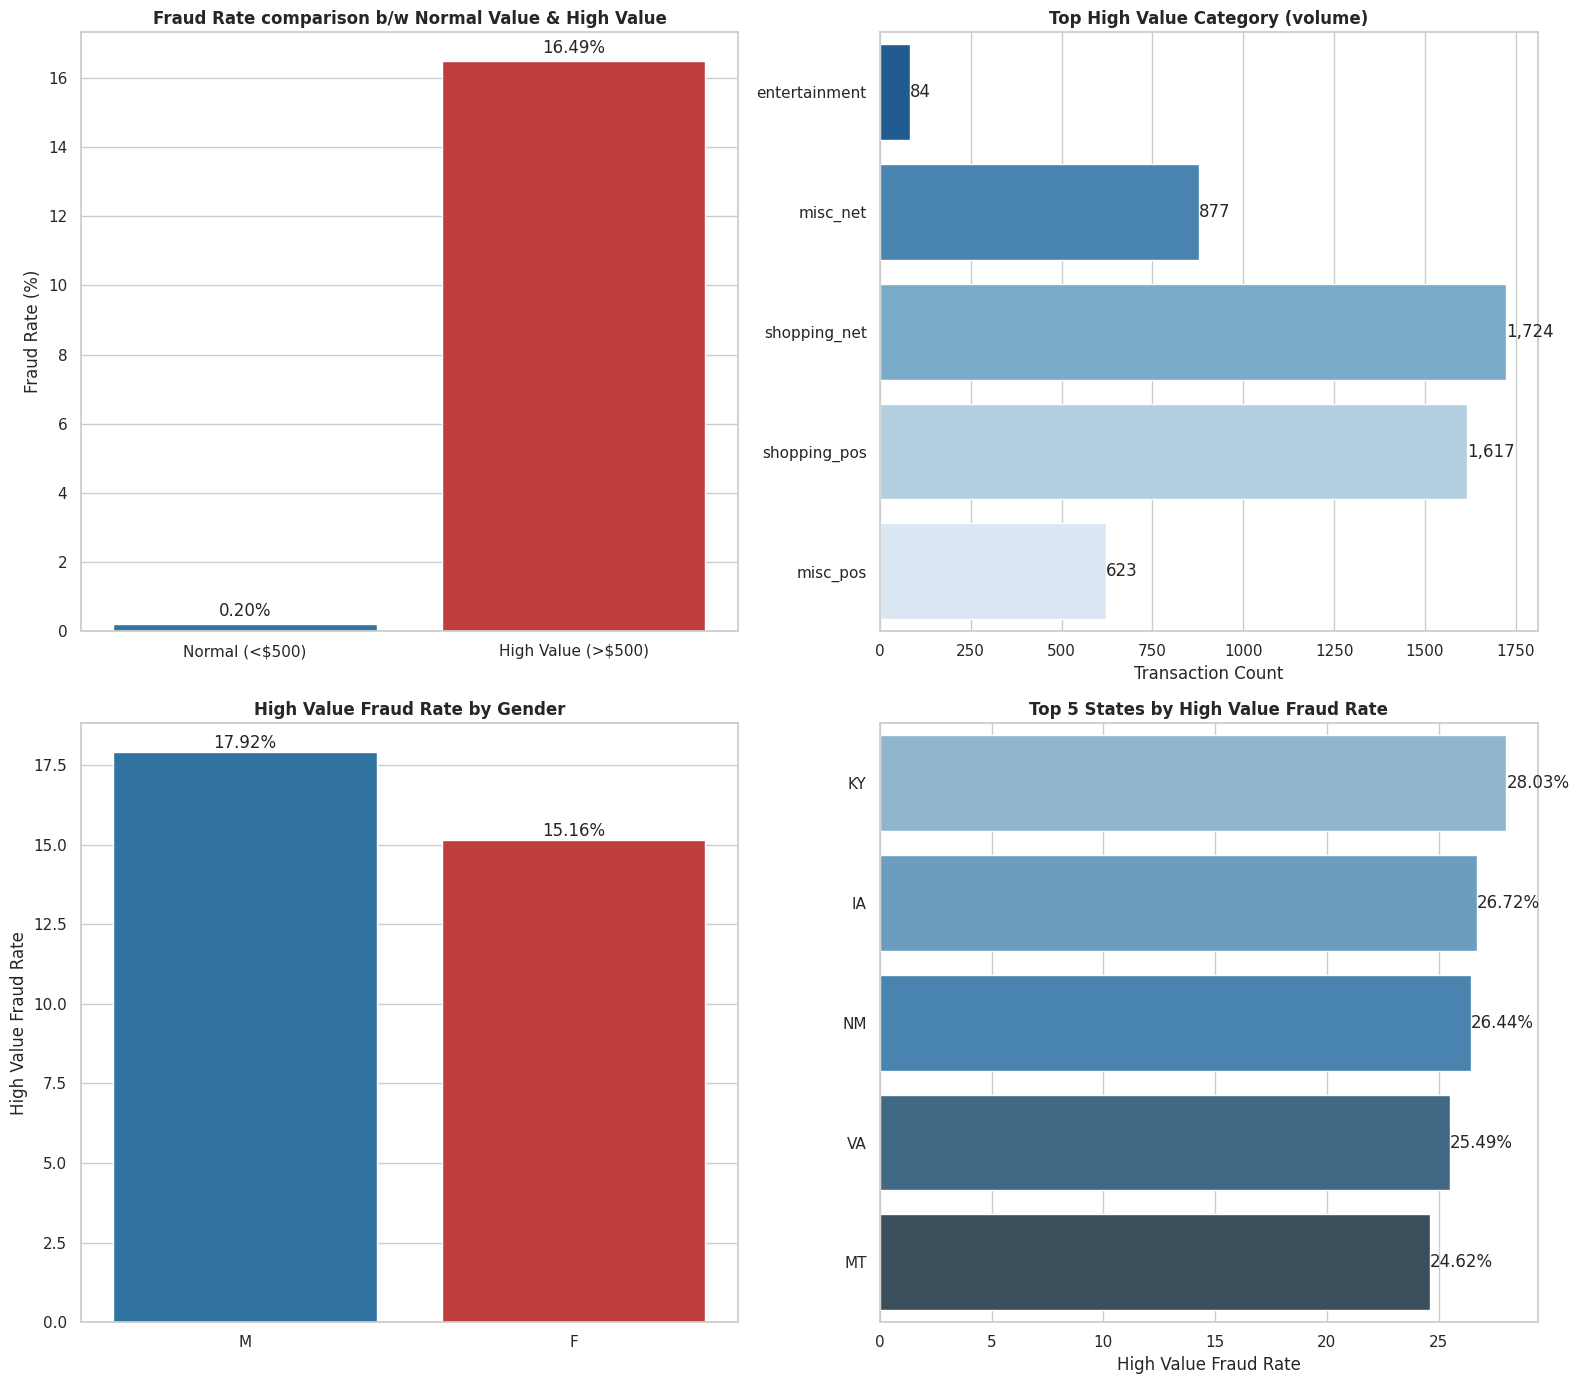

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2,2, figsize=(16,14))

rate_comp = pd.DataFrame({
    'Transaction Type': ['Normal (<$500)', 'High Value (>$500)'],
    'Fraud Rate (%)': [normal_fraud_rate, high_val_fraud_rate]
})
sns.barplot(data=rate_comp, x='Transaction Type', y='Fraud Rate (%)', ax=axes[0,0], palette=['#1f77b4', '#d62728'],hue='Transaction Type')
axes[0,0].set_title('Fraud Rate comparison b/w Normal Value & High Value',fontweight='bold')
axes[0,0].set_xlabel('')
for container in axes[0,0].containers:
  axes[0,0].bar_label(container, fmt='%.2f%%', padding=3)

sns.barplot(x=cat_summary['high_val_count'].head(5), y=cat_summary['category'][:5], ax=axes[0,1], palette='Blues_r', hue=cat_summary['category'][:5])
axes[0,1].set_title('Top High Value Category (volume)', fontweight='bold')
axes[0,1].set_xlabel('Transaction Count')
axes[0,1].set_ylabel('')
for container in axes[0,1].containers:
  axes[0,1].bar_label(container, fmt='{:,.0f}')

sns.barplot(data=gender_summary, x='gender', y='fraud_rate', ax=axes[1,0], palette=['#1f77b4', '#d62728'], hue='gender')
axes[1,0].set_title("High Value Fraud Rate by Gender", fontweight='bold')
axes[1,0].set_ylabel('High Value Fraud Rate')
axes[1,0].set_xlabel('')
for container in axes[1,0].containers:
  axes[1,0].bar_label(container, fmt='%.2f%%')

sns.barplot(x=state_summary['fraud_rate'].head(5), y=state_summary['state'].head(5), ax=axes[1,1], palette='Blues_d', hue=state_summary['state'].head(5))
axes[1,1].set_title('Top 5 States by High Value Fraud Rate', fontweight='bold')
axes[1,1].set_ylabel('')
axes[1,1].set_xlabel('High Value Fraud Rate')
for container in axes[1,1].containers:
  axes[1,1].bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

In [ ]:
df['merchant_clean'] = df['merchant'].str.replace('fraud_', '', regex=False)
df['merchant_clean']

,merchant_clean
0,Johnston-Casper
1,Kuhic LLC
2,"Wuckert, Wintheiser and Friesen"
3,Jast Ltd
4,"Schoen, Kuphal and Nitzsche"
...,...
556464,"Rowe, Batz and Goodwin"
556465,"Koss, Hansen and Lueilwitz"
556466,"Kerluke, Kertzmann and Wiza"
556467,Rutherford-Mertz


In [ ]:
merchant_summary = df.groupby('merchant_clean').agg(
    total_transaction = ('is_fraud', 'count'),
    fraud_transaction = ('is_fraud', 'sum'),
    fraud_trans_rate = ('is_fraud', lambda x:x.mean() * 100),
    total_fraud_loss = ('amt', lambda x:x[df.loc[x.index, 'is_fraud'] == 1].sum())
).reset_index()
top_fraud_merchant = merchant_summary.sort_values(by='fraud_transaction', ascending=False).head(10)
print("=== Top 10 Merchants by Raw Fraud Count ===")
print(top_fraud_merchant.to_string(index=False))

MIN_TRANS = 100
high_risk_merchant = merchant_summary[merchant_summary['total_transaction'] >= MIN_TRANS].sort_values(by='fraud_trans_rate', ascending=False).head(10)
print(f"\n=== Top 10 High-Risk Merchants (Min {MIN_TRANS} Transactions) ===")
print(high_risk_merchant.to_string(index=False))

=== Top 10 Merchants by Raw Fraud Count ===
                      merchant_clean  total_transaction  fraud_transaction  fraud_trans_rate  total_fraud_loss
                       Lemke-Gutmann                838                 18          2.147971          17667.18
Romaguera, Cruickshank and Greenholt                822                 18          2.189781          17627.29
       Mosciski, Ziemann and Farrell                869                 18          2.071346          17888.53
       Heathcote, Yost and Kertzmann                831                 17          2.045728          17445.33
         Schultz, Simonis and Little                989                 17          1.718908           5420.53
                       Heathcote LLC                809                 15          1.854141          14373.62
                         Kilback LLC               1855                 15          0.808625           4214.07
                        Miller-Hauck               1066             

/tmp/ipykernel_607/3914145772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fraud_merchant, x='fraud_trans_rate', y='merchant_clean', ax=axes[1], palette='Oranges_r')


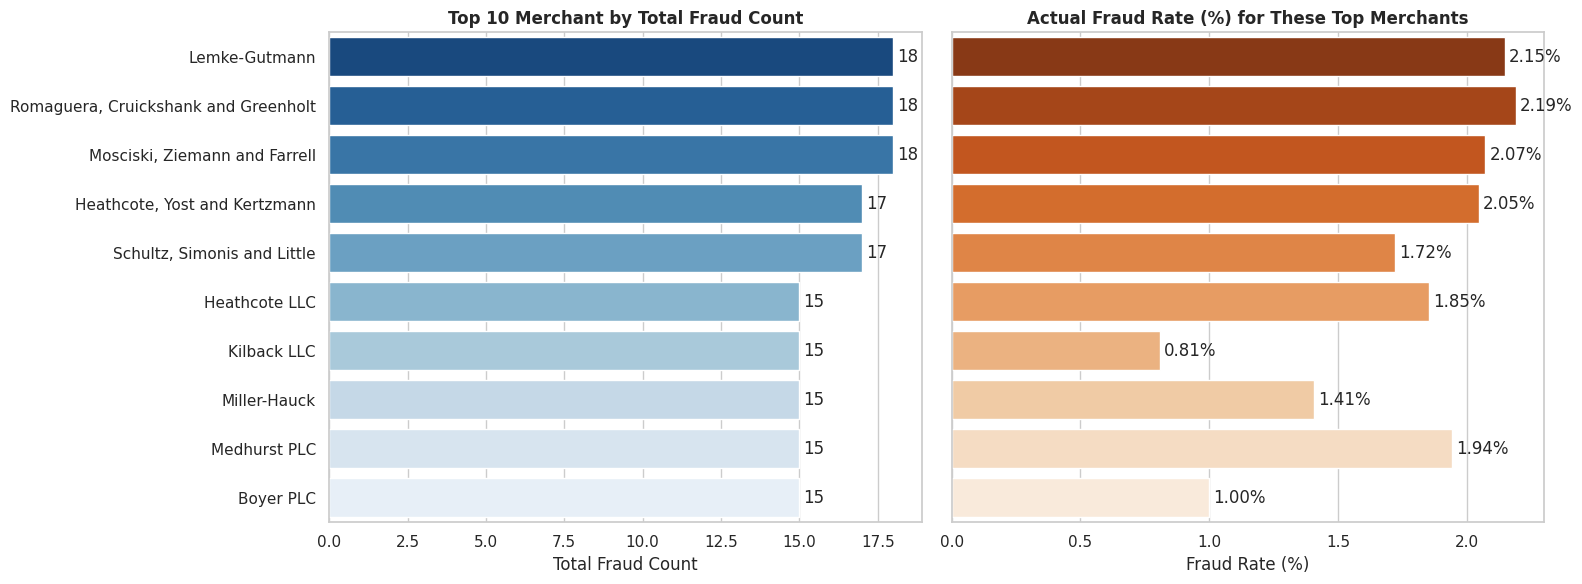

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize= (16,6))

sns.barplot(data=top_fraud_merchant, x='fraud_transaction', y='merchant_clean', palette='Blues_r', ax=axes[0], hue='merchant_clean')
axes[0].set_title('Top 10 Merchant by Total Fraud Count', fontweight='bold', fontsize=12)
axes[0].set_ylabel('')
axes[0].set_xlabel('Total Fraud Count')
for container in axes[0].containers:
  axes[0].bar_label(container, fmt='{:,.0f}', padding=3)

sns.barplot(data=top_fraud_merchant, x='fraud_trans_rate', y='merchant_clean', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Actual Fraud Rate (%) for These Top Merchants', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])  # Remove duplicate Y labels
for container in axes[1].containers:
  axes[1].bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
new_df.to_csv('CreditCardFraudDetectionCleaned.csv', index=False)

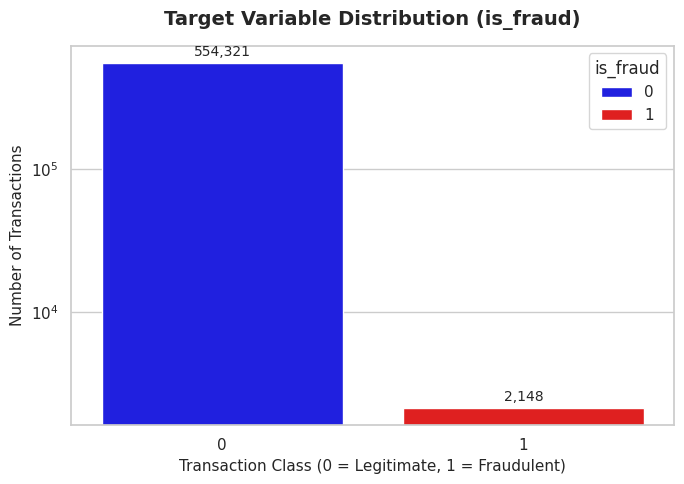

In [ ]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(7,5))

ax = sns.countplot(data=new_df, x='is_fraud', palette=['Blue', 'Red'], hue='is_fraud')
plt.title('Target Variable Distribution (is_fraud)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraudulent)', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.yscale('log')

for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)

plt.tight_layout()
plt.show()